In [1]:
import pandas as pd

# Читаем только первые 100 логических строк (объектов)
# sep=None и engine='python' помогут автоматически определить разделитель (запятая или точка с запятой)
df = pd.read_csv('../data/processed/gold_test_holdout.csv', nrows=100, sep=None, engine='python', encoding='utf-8')

# Сохраняем результат
df.to_csv('../data/processed/gold_test_holdout2.csv', index=False, encoding='utf-8-sig')

print(f"Готово! Сохранено строк по полям: {len(df)}")

Готово! Сохранено строк по полям: 100


📡 Запуск инференса Модели А...


W0608 03:47:52.986000 24028 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


📡 Запуск инференса Модели Б...

Сводная таблица результатов:
        Metric  Model A (Supervised)  Model B (Weak Supervision)
0     Accuracy              0.810000                    0.740000
1     Macro F1              0.819588                    0.672034
2  Weighted F1              0.767502                    0.692974


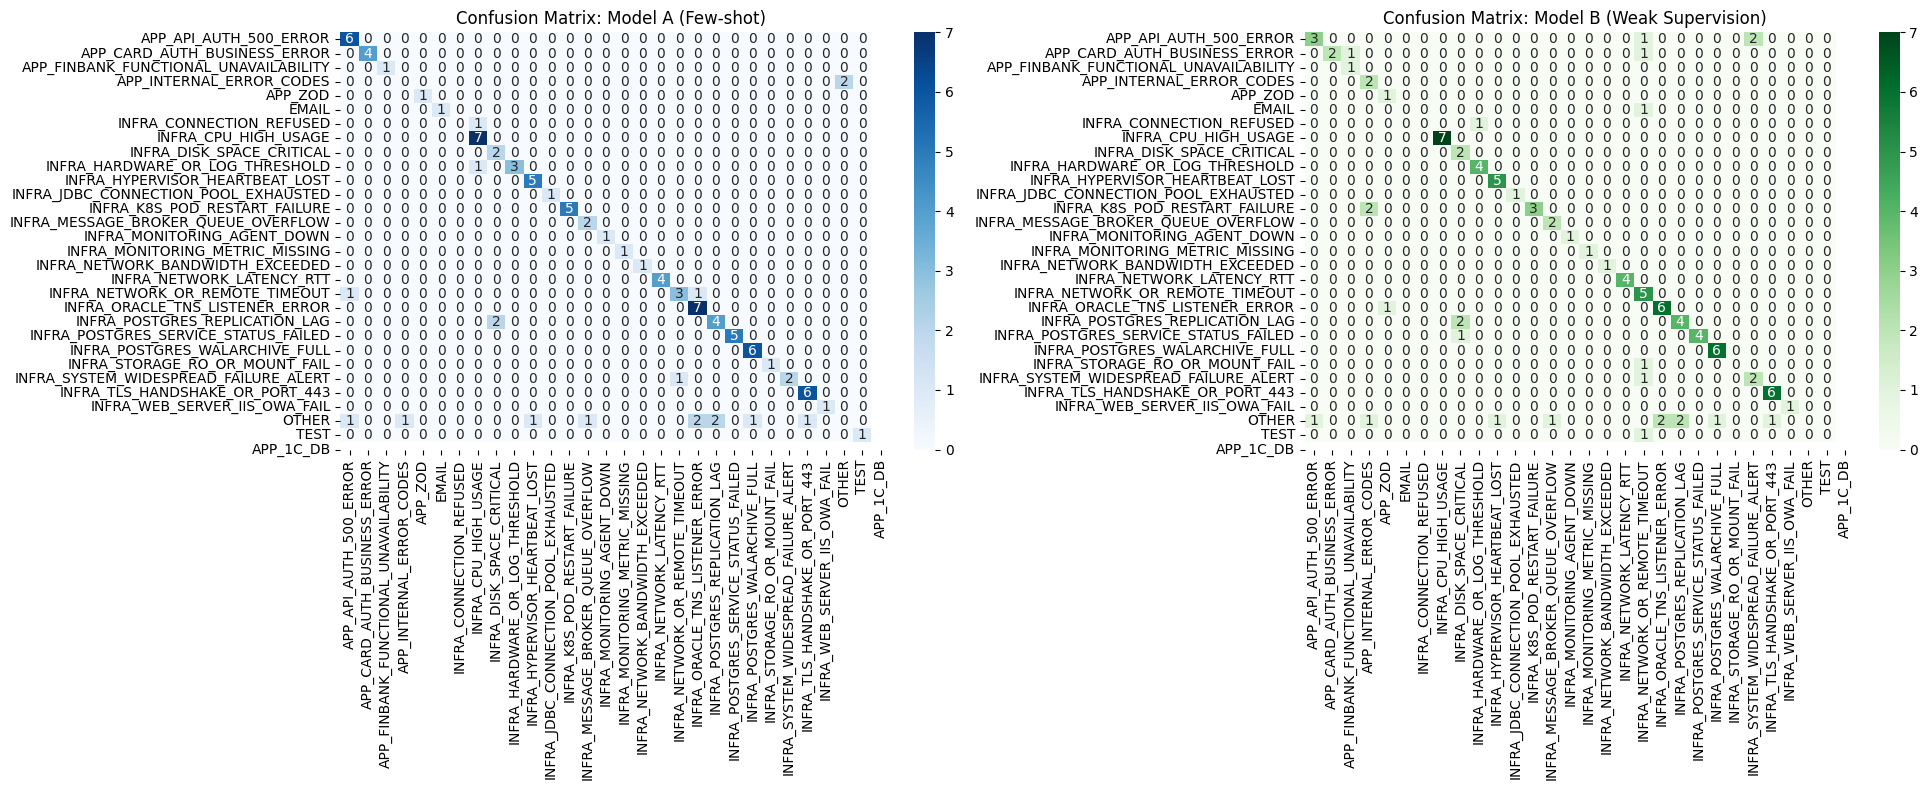


Количество сообщений, которые не поняла ни одна модель: 14
                                                 text  \
2   Авария: EM-04255\r\nИС: SWIFT Gateway\r\nОписа...   
3   Авария: [EM-70934] (https://servicedesk.ru/EM-...   
9   Авария на сетевой инфра структуре [EM-30446] (...   
14  Авария: EM-13940\nИС: Data Warehouse\nОписание...   
18  Авария: EM-10464 \nИС: SWIFT Gateway \nОписани...   

                                    label                           pred_A  \
2                INFRA_CONNECTION_REFUSED             INFRA_CPU_HIGH_USAGE   
3                                   OTHER  INFRA_ORACLE_TNS_LISTENER_ERROR   
9   INFRA_SYSTEM_WIDESPREAD_FAILURE_ALERT  INFRA_NETWORK_OR_REMOTE_TIMEOUT   
14                                  OTHER         APP_INTERNAL_ERROR_CODES   
18                                  OTHER   INFRA_POSTGRES_REPLICATION_LAG   

                             pred_B  
2   INFRA_HARDWARE_OR_LOG_THRESHOLD  
3   INFRA_ORACLE_TNS_LISTENER_ERROR  
9   INFRA_NETW

In [2]:
import pandas as pd
import numpy as np
import torch
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "cointegrated/rubert-tiny"
test_df = pd.read_csv("../data/processed/gold_test_holdout2.csv")
label2id = joblib.load("../../label_encoder_model_a.joblib")
id2label = {i: label for label, i in label2id.items()}
all_labels = list(label2id.keys())

def get_predictions(model_path, texts):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
    model.eval()
    
    preds = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            preds.extend(batch_preds)
    return preds

print("📡 Запуск инференса Модели А...")
y_pred_a = get_predictions("../../saved_model_A_final", test_df['text'].tolist())

print("📡 Запуск инференса Модели Б...")
y_pred_b = get_predictions("../../saved_model_B_final", test_df['text'].tolist())

y_true = test_df['label'].map(label2id).values # если в csv метки текстовые

metrics_data = {
    "Metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "Model A (Supervised)": [
        accuracy_score(y_true, y_pred_a),
        f1_score(y_true, y_pred_a, average='macro'),
        f1_score(y_true, y_pred_a, average='weighted')
    ],
    "Model B (Weak Supervision)": [
        accuracy_score(y_true, y_pred_b),
        f1_score(y_true, y_pred_b, average='macro'),
        f1_score(y_true, y_pred_b, average='weighted')
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("\nСводная таблица результатов:")
print(metrics_df)

# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(confusion_matrix(y_true, y_pred_a), annot=True, fmt='d', cmap='Blues', 
            xticklabels=all_labels, yticklabels=all_labels, ax=ax[0])
ax[0].set_title("Confusion Matrix: Model A (Few-shot)")

sns.heatmap(confusion_matrix(y_true, y_pred_b), annot=True, fmt='d', cmap='Greens', 
            xticklabels=all_labels, yticklabels=all_labels, ax=ax[1])
ax[1].set_title("Confusion Matrix: Model B (Weak Supervision)")

plt.tight_layout()
plt.show()

# АНАЛИЗ ОШИБОК
test_df['pred_A'] = [id2label[i] for i in y_pred_a]
test_df['pred_B'] = [id2label[i] for i in y_pred_b]

errors = test_df[(test_df['label'] != test_df['pred_A']) & (test_df['label'] != test_df['pred_B'])]
print(f"\nКоличество сообщений, которые не поняла ни одна модель: {len(errors)}")
print(errors[['text', 'label', 'pred_A', 'pred_B']].head())